executable_path='./bin/main', system='wsl'
alap_kemia_nelkul_minta.csv
Please check, where you R_dotdot read in from!
[stderr] 2026.02.19 13:32:56: (preprocess) Loaded mechanism "chemkin_kaust2023_ammonia_oxygenless" from "mechanism/json_files/chemkin_kaust2023_ammonia_oxygenless.json" in 12.25 ms. in ./src/parameters.cpp:600: get_parameters();
[stdout] alap_kemia_nelkul_minta.csv
[stderr] 2026.02.19 13:32:56: (postprocess) Dissipated energy is negative: -0.000000 in ./src/ode_solution.cpp:249: postprocess();
[stderr] 2026.02.19 13:32:56: (postprocess) Energy demand is negative: -8461122715559842.000000 in ./src/ode_solution.cpp:321: postprocess();

./bin/main returned with code 0 after 0.4103 seconds.


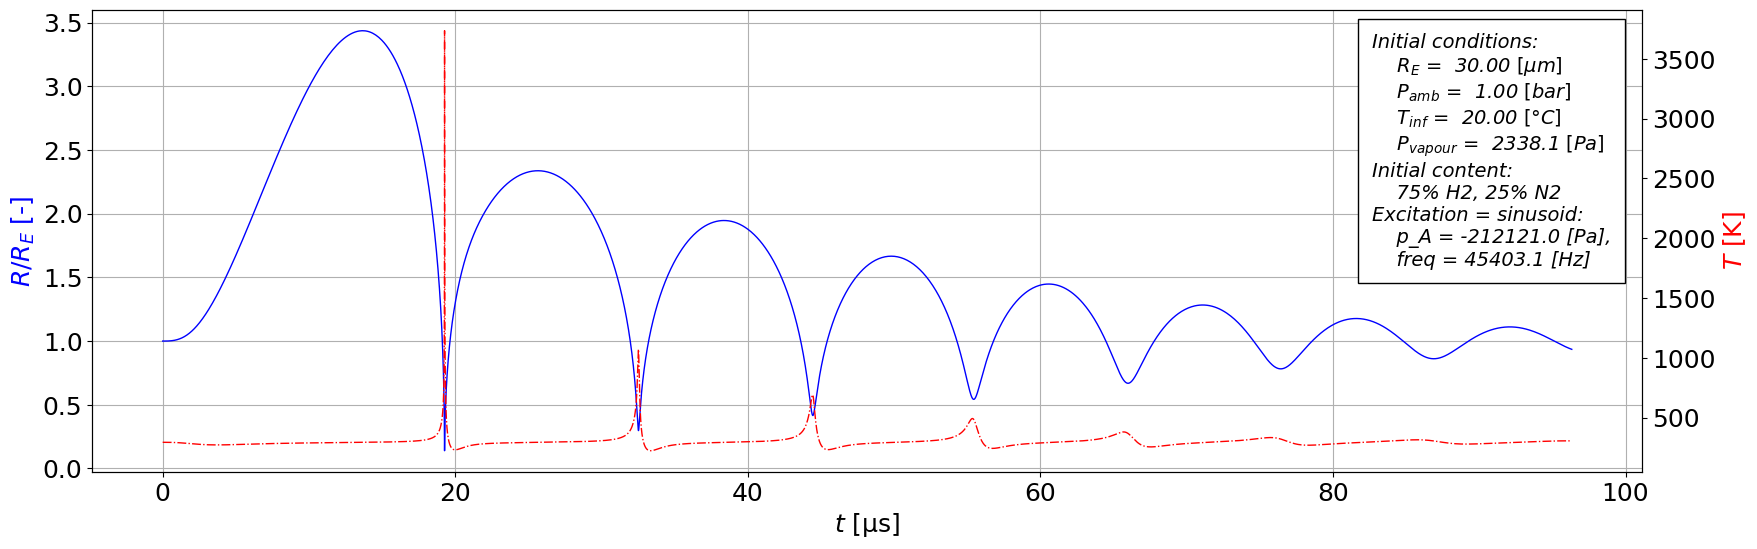

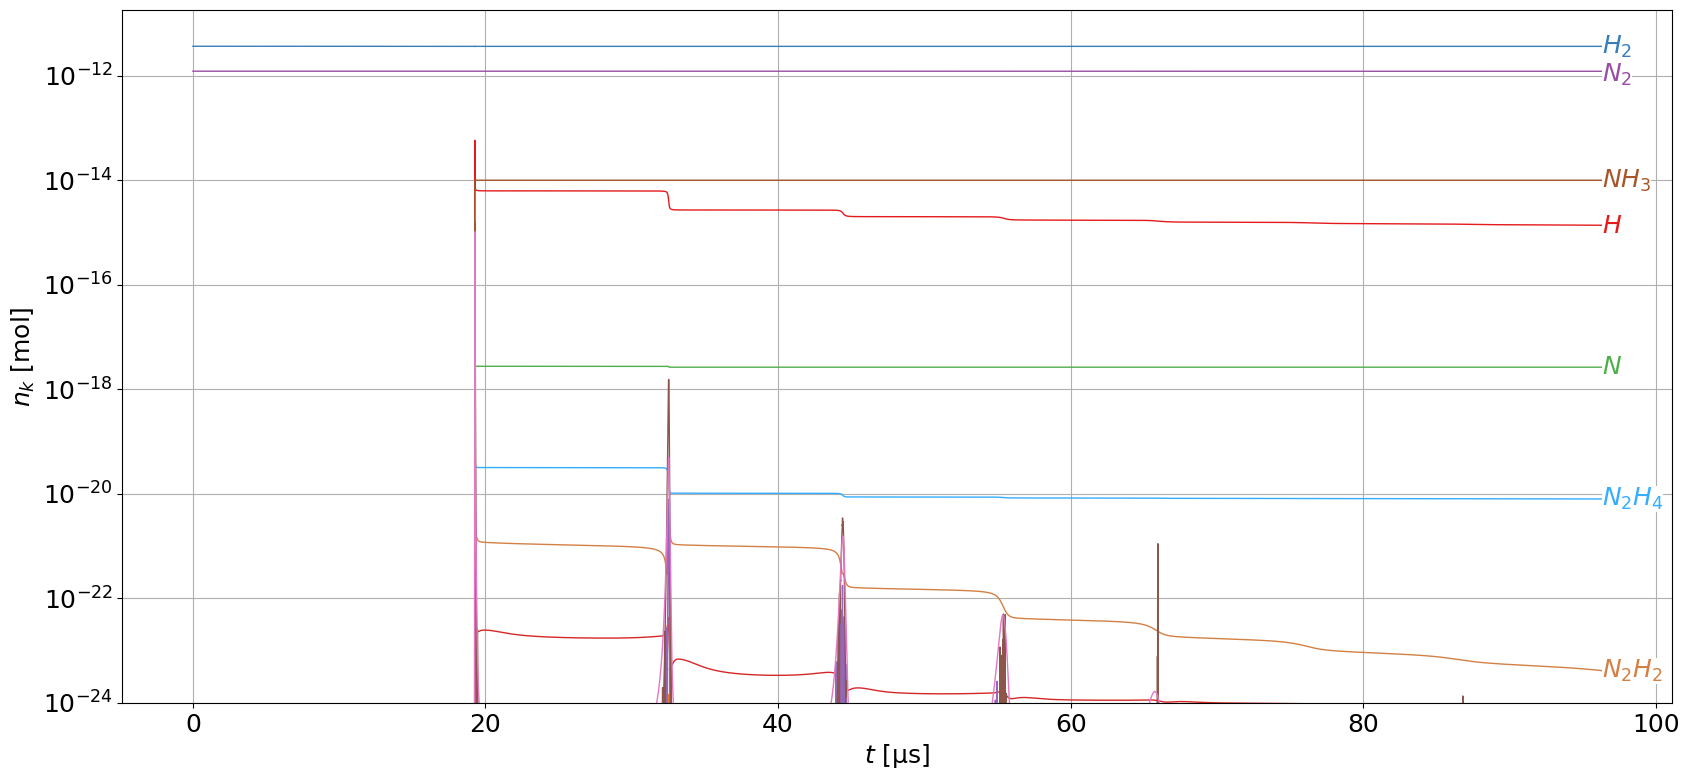

IndexError: index 5168 is out of bounds for axis 0 with size 5168

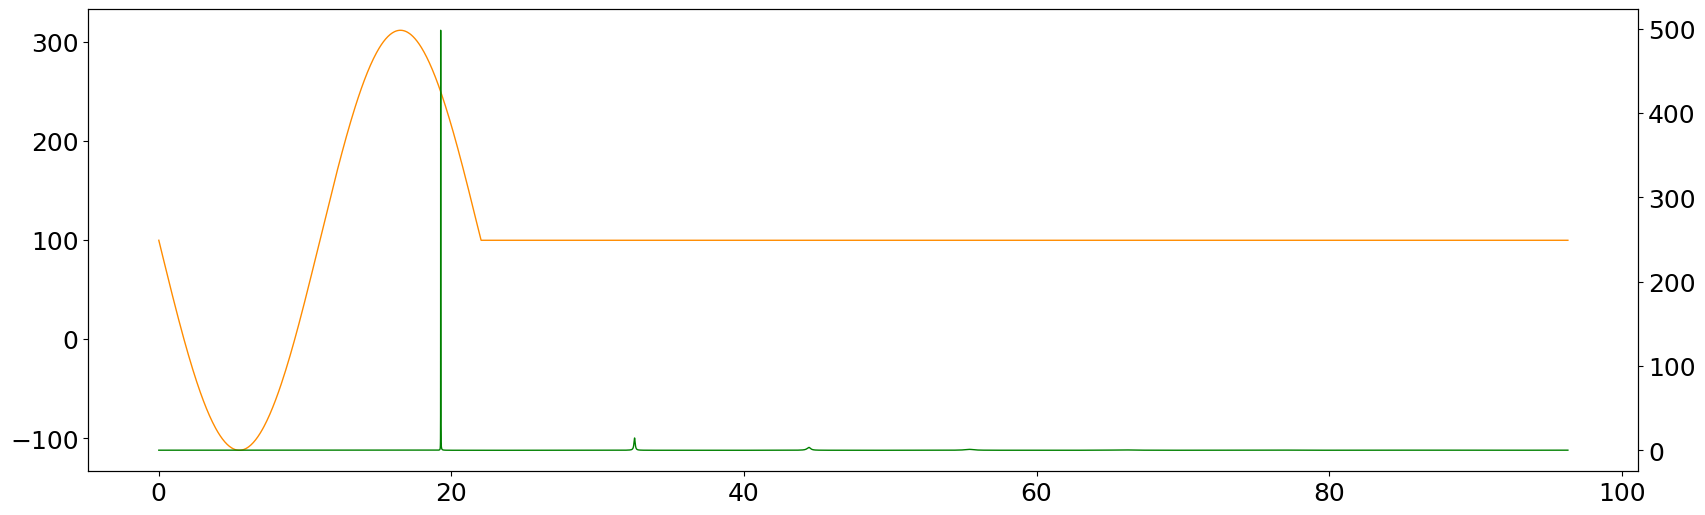

In [20]:
import importlib
from interface import python_interface as api
importlib.reload(api)
cpar=api.example_cpar()

cpar = {'ID': 0,
 'mechanism': 'chemkin_kaust2023_ammonia_oxygenless',
 'R_E': 30.0e-06,
 'ratio': 1.0,
 'species': ['H2','N2'],#['H2','N2','O2','AR','HE','H2O'],#['N2H3','O','NH2','NO','H'],
 'fractions': [0.75,0.25],#[0.25,0.20,0.05,0.07,0.12,0.31],#[0.3,0.25,0.2,0.15,0.1],
 'P_amb': 1.0e5,#101325.0,
 'T_inf': 293.15,
 'alpha_M': 0.35,
 'P_v': 2338.1,
 'mu_L': 0.001,
 'rho_L': 998.2,
 'c_L': 1483.0,
 'surfactant': 1.0,
 'enable_heat_transfer': True,
 'enable_evaporation': False,
 'enable_reactions': True,
 'enable_dissipated_energy': True,
 'enable_van_der_waals': True,
 'enable_rate_thresholding': True,
 'target_specie': 'NH3',
 'excitation_type': 'sinusoid',#'no_excitation',#'sinusoid',#'sin_impulse',
 'excitation_params': [-2.12121e5, 45.4031e3],#[-2.12121e5, 45.4031e3],# [],
 #'excitation_type': 'sin_impulse',
 #'excitation_params': [-2.12121e5, 45.4031e3, 1], 
 'excitation_cycles': 1.0,
 'ramp_up_cycles': 0.0,
 'extra_data_from_here': 1, #1: R_dotdot is calculated here, 0: it is read from *.csv
 'rows': 1,
 'cols': 1,
 'file_name': 'alap_kemia_nelkul_minta.csv',#'alap_kemia_nelkul_minta.csv'
       }
print(cpar['file_name'])
print('Please check, where you R_dotdot read in from!')

data=api.run_simulation(cpar,executable_path="./bin/main",t_max=0.0001,timeout=300.0,save_steps=True)
#cpar: dict, json_path: str = 'ignore.json', executable_path: str = './bin/main', t_max: float = 1.0, timeout: float = 60.0, save_steps: bool = True, save_jacobian: bool = False, show_output: bool = True
api.plot(data)

#ps=api.example_parameter_study()
#api.run_parameter_study(ps,save_directory='par_study')

#datas=api.read_parameter_study('par_study1/')

In [23]:
print('Please check if the data in parameters.py is correct (accurate mechanism...)!')
class dotdict(dict):
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

import importlib   # For reloading your own files
import full_bubble_model as de
importlib.reload(de)
import parameters as par   # numeric constants and coefficents
importlib.reload(par)   # reload changes you made
file = de.Make_dir('_test', separator=',')   # it makes a folder named 'test' in which it will save data
num_sol=data['sol']
error_code=-1
elapsed_time=-1

num_sol = dotdict(data['sol'])
num_sol.y = num_sol.x.T.copy()
#num_sol.y[3:-1,:] = num_sol.y[3:-1,:]*1.0e-6#*1.0e-6: mol/m^3->mol/cm^3
#!!!! data.success = num_sol.success

data2 = de.get_data(cpar, num_sol, error_code, elapsed_time)   # post processing
file.write_solution(data2, num_sol, 'testfile')   # saving (it overwrites data)

Please check if the data in parameters.py is correct (accurate mechanism...)!
model: chem_KAUST2023_N2_carbonfree_without_O_FIXED_by_Cantera
target specie: NH3
excitation: no_excitation (control parameters: [])
enable heat transfer: True	enable evaporation: False	enable reactions: True	enable dissipated energy: True	enable reaction rate threshold: True	enable_time_evaluation_limit: False
Folder already exists with 2 csv in it


In [ ]:
datas[['p_A', 'freq', 'n', '_']] = datas['excitation_params'].str.split(';', expand=True)
matrix = datas.pivot(index="R_E", columns="p_A", values='energy_demand')
print(matrix)

In [1]:
#from matplotlib import pyplot as plp
#import numpy as np
#matrix=np.minimum(matrix,1000)
#matrix=np.maximum(matrix,100000)
#plp.imshow(matrix)